In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_excel("ABC Company.xlsx") 
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


### Preprocessing

In [49]:
df['height'] = np.random.randint(150, 181, size=len(df))


### Analysis Tasks

##### 1. Distribution of Employees by team 



In [50]:
team_stats=df['Team'].value_counts()
team_pct=(team_stats/len(df))*100

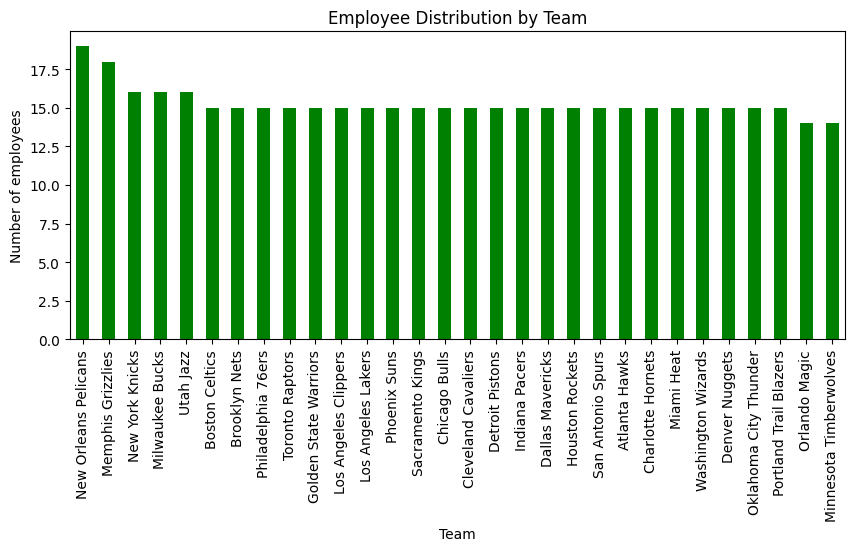

In [51]:
plt.figure(figsize=(10,4))
team_stats.plot(kind='bar',color='green')
plt.title('Employee Distribution by Team')
plt.ylabel('Number of employees')
plt.show()

In [52]:
position_stats = df['Position'].value_counts()
print(position_stats)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


##### Findings:
Based on our visualization, the workforce is spread across many teams, but the New Orleans Pelicans and Memphis Grizzlies are the largest departments, with approximately 18 to 19 employees each.
##### Insights:
This suggests that these two teams are the primary operational hubs of the company. Most other teams are very balanced, maintaining a consistent size of about 15 employees.

##### 2. Segregate employees by positions

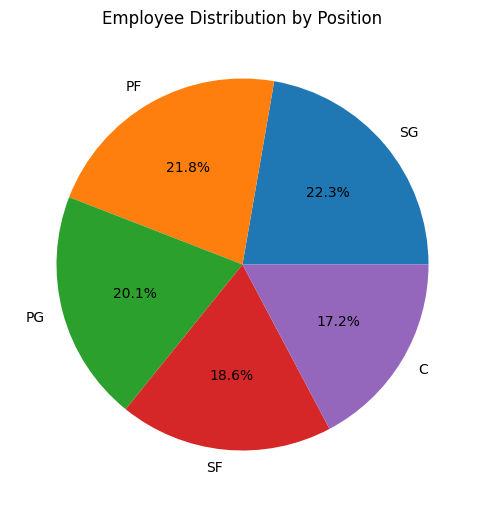

In [53]:
plt.figure(figsize=(6,8))
plt.pie(position_stats,labels=position_stats.index,autopct='%1.1f%%')
plt.title('Employee Distribution by Position')
plt.show()

##### Findings
Our analysis shows that SG (Shooting Guards) make up the largest portion of the workforce at 22.3%, followed closely by PF (Power Forwards) at 21.8%. The least represented position is C (Center) at 17.2%.
##### Insights
The company has a very even distribution across all roles, with no single position overwhelmingly dominating the others. This suggests a well-balanced team structure where different specialized roles are given nearly equal importance.


##### 3. Predominant Age Group

In [54]:
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60]
labels = ['20-24', '25-29', '30-34','35-39','40-44','45-49','50-54','55-59']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
print(df['Age Group'].value_counts())


Age Group
25-29    182
20-24    152
30-34     90
35-39     29
40-44      3
45-49      0
50-54      0
55-59      0
Name: count, dtype: int64


C:\Users\chikk\AppData\Local\Temp\ipykernel_16540\2389699862.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age Group',palette='viridis')


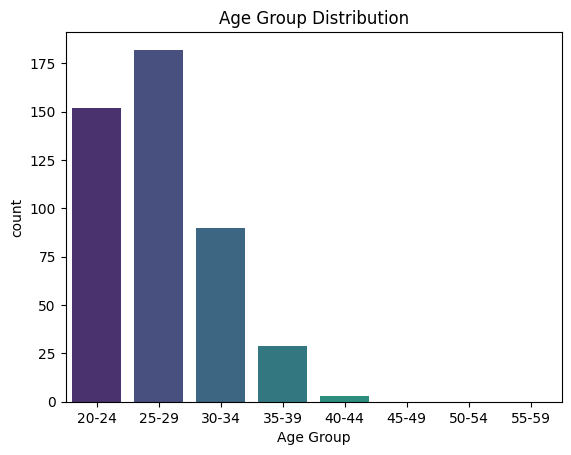

In [55]:
sns.countplot(data=df, x='Age Group',palette='viridis')
plt.title('Age Group Distribution')
plt.show()

##### Findings:
The predominant age group in ABC Company is 25-29, with the second-largest group being 20-24. Collectively, employees under 30 make up the vast majority of the workforce.
##### Insights:
The company has a very young, entry-to-junior level demographic. This suggests a vibrant, high-growth environment, but it also highlights a potential "experience gap" as there are very few employees over the age of 40.


##### 4. Highest Salary Expenditure

In [56]:
team_salary = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
position_salary = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)
print(f"Highest Salary Team:{team_salary.idxmax()}")
print (f"Highest Salary Position:{position_salary.idxmax()}")

Highest Salary Team:Cleveland Cavaliers
Highest Salary Position:C


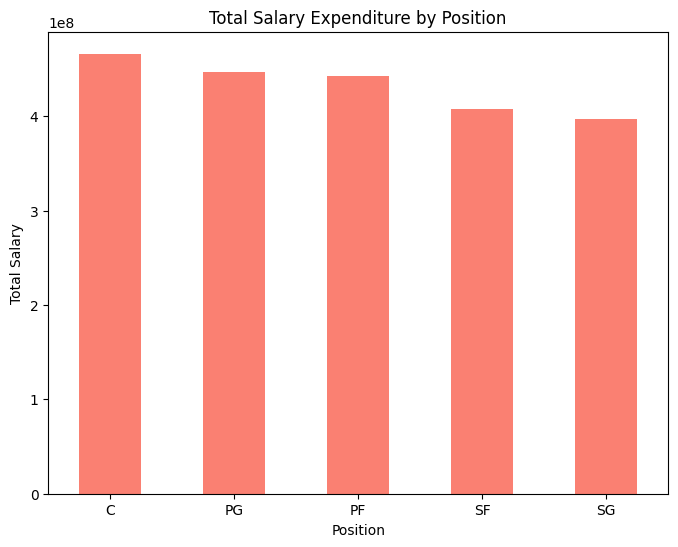

In [57]:
plt.figure(figsize=(8, 6))
position_salary.plot(kind='bar',color='salmon')
plt.title('Total Salary Expenditure by Position')
plt.xlabel('Position')
plt.ylabel('Total Salary')
plt.xticks(rotation=0)
plt.show()

##### Findings:
The Cleveland Cavaliers have the highest salary expenditure among all teams. When looking at roles, the Center (C) position accounts for the largest portion of the budget.
##### Insights:
This suggests that the Cavaliers may have a higher concentration of Star players or that the company prioritizes the Center position financially more than guards or forwards.

##### 5. Coerrelation Between age and salary 

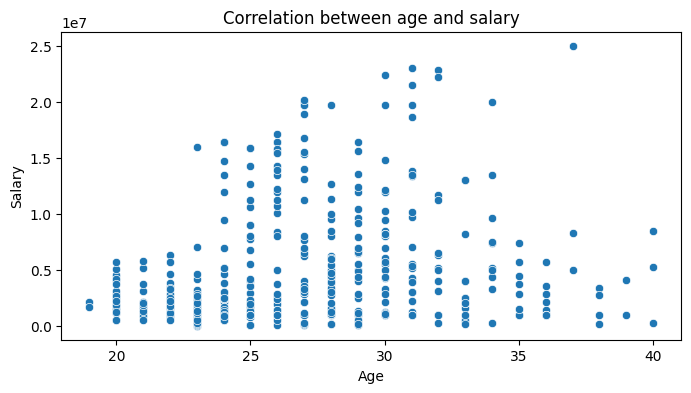

In [58]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Age',y='Salary')
plt.title('Correlation between age and salary')
plt.show()

In [59]:
correlation=df['Age'].corr(df['Salary'])
print(f"Correlation Coefficient:{correlation}")

Correlation Coefficient:0.21400941226570971


##### Findings:
Our correlation coefficient is 0.21, visualized by a scattered distribution in the scatter plot.
##### Insights:
There is a weak positive correlation between age and salary. While pay does increase slightly with age, many young employees are already in high-earning brackets. This suggests that ABC Company rewards position and merit more heavily than just years of seniority.


#### **Data Story**
Our analysis of ABC Company reveals a dynamic, youth-driven organization. The company’s strategy focuses on a balanced distribution of roles, with a slight emphasis on "wing" positions (SG and PF).

* **Team Distribution:** State that the New Orleans Pelicans and Memphis Grizzlies are the largest teams.
* **​Position Segregation:** Note that Shooting Guards (SG) are the most common role at 22.3%.
* **​Age Demographics:** Explain that the 25–29 age group is the most predominant.
* **​Salary Expenditure:** Mention that the Cleveland Cavaliers spend the most on salaries, and the Center (C) position has the highest role-based expenditure.
* **​Correlation:** Conclude that there is a weak positive correlation (0.21) between age and salary, suggesting pay is based more on position than seniority.